# Customer Churn Prediction — Exploratory Data Analysis(EDA)

# Problem Statement
Telecom companies lose significant revenue due to customer churn.
This analysis explores the Telco Customer Churn dataset to identify
key patterns and factors that lead customers to cancel their subscription.

# Dataset
- Source: IBM Telco Customer Churn Dataset (Kaggle)
- Rows: 7043 customers
- Columns: 21 features
- Target: Churn (Yes/No)

In [19]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# Load Dataset
BASE_DIR = Path().resolve()
df = pd.read_csv(BASE_DIR / "data" / "Telco-Customer-Churn.csv")
print(df.head(5))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [20]:
print("Dataset Shape :", df.shape)
print(df.columns.tolist())
df.info()                         # The dataset contains both numerical and categorical features.
df.describe()                     # MonthlyCharges and tenure exhibit significant variability.
print(df.isnull().sum())
print("Duplicate Rows :", df.duplicated().sum())

Dataset Shape : (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null

# 1. Churn Distribution
Checking how balanced our dataset is between churned and retained customers.

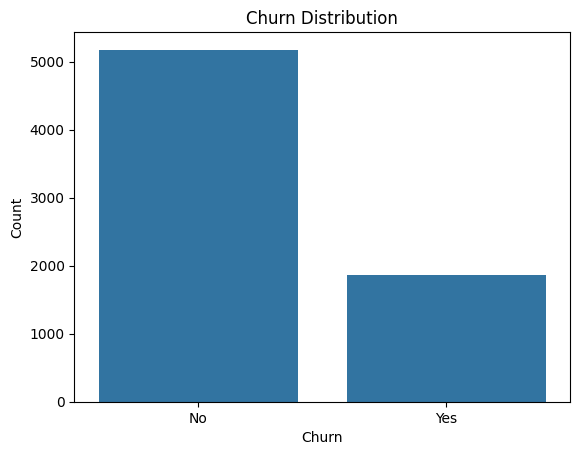

In [21]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Finding 1:
73.5% customers retained (5174) vs 26.5% churned (1869).
Dataset is imbalanced , this will be handled during preprocessing.

# 2. Tenure vs Churn
Checking whether customer tenure affects churn rate.
New customers vs long term customers.

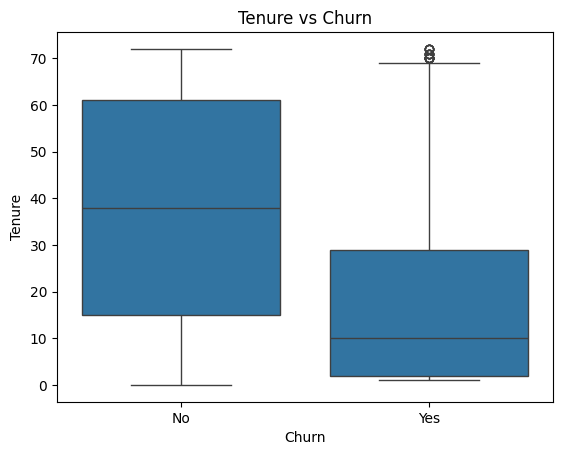

In [22]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

# Finding 2:
Churned customers have median tenure of only 10 months
and 38 months for retained customers.
New customers are significantly more likely to churn.
Long term customers show strong loyalty.

# 3. Monthly Charges vs Churn
Checking whether Monthly Charges affects churn rate.

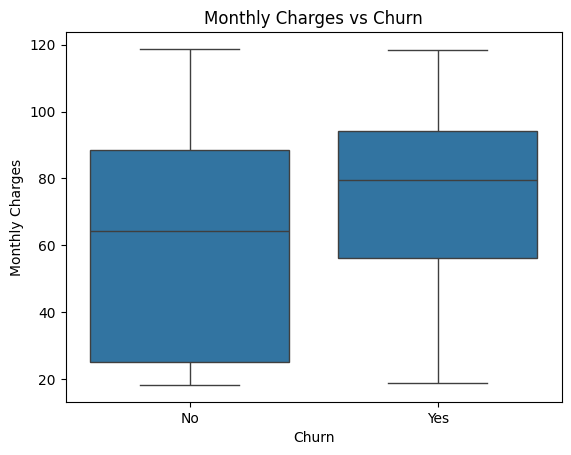

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

# Finding 3:
Customers who did not churn have relatively lower median monthly charges 64.7
than customers who churned whose median monthly charges is around 82. 
Customers with less monthly charges are not much likely to churn while high monthly charges are more likely to churn.

# 4. Contract Type vs Churn
Checking which type of contract types affects churn rate.
Contract Type Strongly Affects Retention.

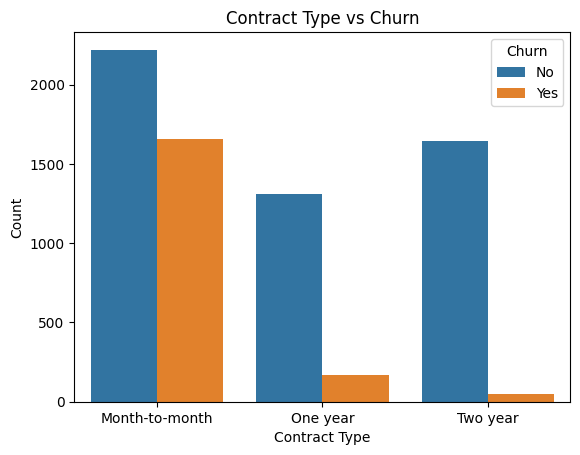

In [24]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

# Finding 4:
Customers with more tenure contract type is more likely not to churned out compared to month to month contract type. 
It shows strong relationship between tenure and contract type time period."

# 5. Payment Method vs Churn
Checking which type of payment method affects the most to churn rate.


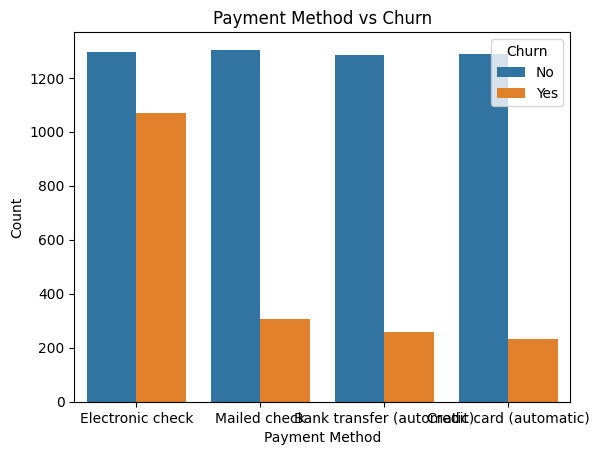

In [25]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()


# Finding 5:
Customers using Electronic Check have highest churn count. Customers using 
Mailed Check, Bank Transfer and Credit Card show significantly lower churn.
 Automatic payment methods are associated with better 
 customer retention while Electronic Check users are at higher risk.

# 6. Heat Map Correlation
Checking which are the features correlated the most.

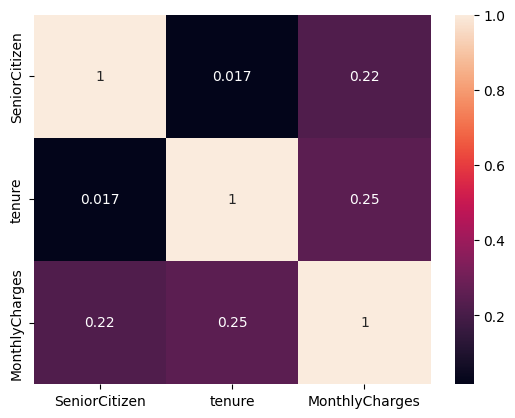

In [26]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(data = corr,annot=True)
plt.show()

# Finding 6:
Heatmap shows weak positive correlations among numeric features. 
Tenure and MonthlyCharges have highest correlation of 0.25 indicating
 slight tendency for customers with longer tenure to have higher monthly charges.

# 7. Senior Citizen vs Churn
Checking how senior citizen status influences customer churn.

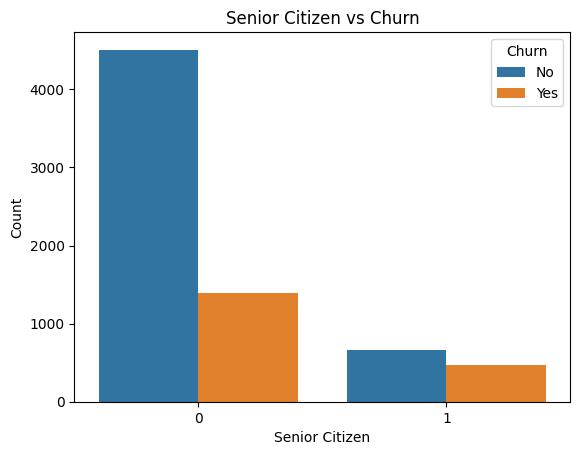

In [27]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")
plt.show()


# Finding 7:
Senior citizens have a higher churn rate than non-senior customers. 
Most customers are non-senior, but a larger proportion of senior citizens leave the service.


#  Summary 
• Dataset contains 7043 customer records.
• No missing values had found.
• No duplicate rows were found.
• Dataset is imbalanced with more non-churn customers.
• Customers with shorter tenure are more likely to churn.
• Higher monthly charges are associated with higher churn.
• Customers on month-to-month contracts exhibit higher churn.
• Electronic check users show higher churn rates.
• Senior citizens have a relatively higher churn rate.
• Numerical features show only moderate correlation, indicating low multicollinearity.